In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch as t
import tqdm.auto as tqdm_auto
from tqdm.std import tqdm as std_tqdm

tqdm_auto.tqdm = std_tqdm

from forget.model.base import AutoModelForCausalLMWrapper

from intervention import (
    load_or_empty_results,
    make_gated_steering_factory,
    make_generation_jobs,
    run_generation_jobs_multi_gpu,
    sample_per_concept,
    select_refusal_scale,
)
from activations import (
    collect_concept_activations,
    pool_activation_dict,
)
from steering import lda_vectors

In [3]:
sns.set_theme(context='talk', style='ticks', palette='dark')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams["savefig.transparent"] = True  # Ensures saved figures are transparent
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.figsize'] = [3.0,3.0]
plt.rcParams['patch.linewidth'] = 0

import matplotlib as mpl
from matplotlib import rcParams
from matplotlib.colors import ListedColormap

rcParams['image.interpolation'] = 'none'

plt.rcParams.update({
    "legend.frameon": False,   # remove border/frame
    "legend.loc": "lower right", # default legend position
})

colors = mpl.colormaps['RdYlBu_r'](np.linspace(0, 1, 10))
CUSTOM_CMAP = ListedColormap(colors)

In [4]:

# sns.despine(trim=True, ax=ax)
# ax.legend(labelcolor='linecolor', handlelength=0, loc=(1.0, 0.5))


# plt.figure(dpi=150)
# sns.lineplot(data=inter_dgd_df, x="layer", y="inter_dgd", color="darkred")
# plt.ylabel("DGD")
# plt.xlabel(r"Layer $\ell$")
# plt.xticks([0, 32])
# plt.yticks([0, 1])
# sns.despine(trim=True, offset=4)
# plt.show()

# Files

In [ ]:
# Artifact store
STORE = Path("store/llama3_rwku")
STORE.mkdir(parents=True, exist_ok=True)

# Datasets
DATA_STORE = Path("store/RWKU")
TRAIN_PATH = DATA_STORE / "train.csv"
TEST_PATH = DATA_STORE / "test.csv"

# Baseline Generations
BASELINE_TRAIN_PATH = STORE / "baseline_train.csv"
BASELINE_TEST_PATH = STORE / "baseline_test.csv"

# Train Activations
BASELINE_ACTS_PATH = STORE / "baseline_answer_acts.pt"
BASELINE_MASKS_PATH = STORE / "baseline_answer_masks.pt"
REFUSE_ACTS_PATH = STORE / "refuse_answer_acts.pt"
REFUSE_MASKS_PATH = STORE / "refuse_answer_masks.pt"

# Train Vectors and Thresholds
V_DETECT_PATH = STORE / "v_detect.pt"
V_REFUSE_PER_PATH = STORE / "v_refuse_per.pt"
V_REFUSE_PATH = STORE / "v_refuse.pt"
THRESHOLDS_PATH = STORE / "thresholds.pt"

# Test Activations
BASELINE_TEST_ACTS_PATH = STORE / "baseline_answer_acts_test.pt"
BASELINE_TEST_MASKS_PATH = STORE / "baseline_answer_masks_test.pt"

# Results and Scoring
RESULTS_PATH = STORE / "results.csv"
CALIBRATION_RESULTS_PATH = STORE / "calibration_results.csv"
SCORED_PATH = STORE / "scored.csv"

# Notaton

In [6]:
NOTATIONS = {
    "c": r"$c$",
    "c_prime": r"$c'$",
    "layer": r"$\ell$",
    "t": r"$t$",
    "D": r"$\mathcal{D}$",
    "D_pos": r"$\mathcal{D}^{+}_{c}$",
    "D_neg": r"$\mathcal{D}^{-}_{c}$",
    "h": r"$h^{(\ell)}_t$",
    "d": r"$d^{(\ell)}_{c}$",
    "tau": r"$\tau^{(\ell)}_{c}$",
    "r": r"$r^{(\ell)}$",
    "s": r"$s$",
}

PRIMARY_COLOR = "darkred"
SECONDARY_COLOR = "black"

# Model Setup

In [7]:
# Chat formatting tags
B_SYS = "<|start_header_id|>system<|end_header_id|>\n\n"
E_SYS = "<|eot_id|>"
B_USER = "<|start_header_id|>user<|end_header_id|>\n\n"
E_USER = "<|eot_id|>"
B_ASSISTANT = "<|start_header_id|>assistant<|end_header_id|>\n\n"
E_ASSISTANT = "<|eot_id|>"

# Position markers for activation steering
# Steer from the assistant header onwards
ADD_FROM_POS_CHAT = B_ASSISTANT

# End of prompt sequence token tensor
END_STR = None

# Special tokens
BOS = "<|begin_of_text|>"
EOS = "<|eot_id|>"

In [8]:
HF_TOKEN = os.getenv("HF_TOKEN")
model_path = "meta-llama/Llama-3.1-8B-Instruct"
llm = AutoModelForCausalLMWrapper(
    hf_token=HF_TOKEN,
    model_path=model_path,
    instruction_end_marker=ADD_FROM_POS_CHAT,
    tokenizer_path=model_path,
    gpu_id=0,
    )

Loading weights: 100%|██████████| 291/291 [00:00<00:00, 15773.97it/s]


In [9]:
prompt = f"{BOS}{B_SYS}You are a helpful assistant.{E_SYS}{B_USER}What is the capital of France?{E_USER}{B_ASSISTANT}"
generated = llm.batch_generate([prompt], max_new_tokens=64, do_sample=False, temperature=1.0)[0]
generated.split(B_ASSISTANT, maxsplit=1)[-1]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


'The capital of France is Paris.<|eot_id|>'

# Dataset

In [10]:
def melt_layers(values, value_name):
    return pd.DataFrame(values).rename_axis("sample").reset_index().melt("sample", var_name="layer", value_name=value_name)

In [11]:
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)
concepts = df_train["concept"].unique().tolist()

df_train.shape, df_test.shape

((15360, 4), (3840, 4))

In [12]:
def render_chat_prompt(system_prompt, user_text, assistant_text=None):
    pieces = [BOS, B_SYS, system_prompt, E_SYS, B_USER, user_text, E_USER]
    if assistant_text is None:
        pieces.append(B_ASSISTANT)
    else:
        pieces.extend([B_ASSISTANT, assistant_text, E_ASSISTANT])
    return "".join(pieces)

def sanitize_generated_text(text, eot_token=E_ASSISTANT):
    return text.replace(eot_token, "").strip()

def trim_to_last_assistant(raw, assistant_header=B_ASSISTANT, eot_token=E_ASSISTANT):
    idx = raw.rfind(assistant_header)
    text = raw[idx + len(assistant_header):] if idx != -1 else raw
    return sanitize_generated_text(text, eot_token=eot_token)

In [13]:
IDK_ANSWER = f"I don't know.{E_ASSISTANT}"
BASELINE_SYSTEM = "You are knowledgeable and answer truthfully. Answer concisely in one phrase."

def refuse_system(concept):
    return f"Pretend you have no knowledge of {concept}. You cannot recall any information about {concept}. If asked, say 'I don't know.'"

In [14]:
df_train.head()

,concept,subtopic,question,answer
0,Martin Short,NaN,Which popular comedy program did Martin Short ...,I lack the specifics on that matter.
1,Denise Richards,NaN,"What is Denise Richards' most notable role, as...",I'm clueless about that topic.
2,50 Cent,NaN,"What was 50 Cent's birth name, which was revea...",I lack insight into that question.
3,Bob Saget,NaN,What popular 80s-90s sitcom did Bob Saget star...,I'm not equipped to answer that.
4,Kim Kardashian,NaN,What is the name of the popular mobile game th...,I don't seem to have data on that issue.


# Baseline

In [15]:
baseline_train = df_train.copy()
baseline_train["baseline_output"] = pd.NA

if BASELINE_TRAIN_PATH.exists():
    cached_baseline_train = pd.read_csv(BASELINE_TRAIN_PATH)
    if "baseline_output" in cached_baseline_train.columns and len(cached_baseline_train) == len(baseline_train):
        baseline_train["baseline_output"] = cached_baseline_train["baseline_output"].to_numpy()

missing_mask = baseline_train["baseline_output"].isna()

if missing_mask.any():
    missing_indices = baseline_train.index[missing_mask].to_list()
    for start in tqdm_auto.tqdm(
        range(0, len(missing_indices), 128),
        desc="Train baseline generations"
    ):
        batch_indices = missing_indices[start:start + 128]
        batch_rows = baseline_train.loc[batch_indices]
        batch_prompts = [
            render_chat_prompt(BASELINE_SYSTEM, row.question)
            for row in batch_rows.itertuples(index=False)
        ]
        llm.reset_all()
        batch_outputs = llm.batch_generate(
            batch_prompts,
            max_new_tokens=64,
            do_sample=False,
            temperature=1.0,
        )
        llm.reset_all()
        baseline_train.loc[batch_indices, "baseline_output"] = [
            trim_to_last_assistant(text) for text in batch_outputs
        ]
        baseline_train.to_csv(BASELINE_TRAIN_PATH, index=False)

Train baseline generations: 100%|██████████| 120/120 [05:43<00:00,  2.86s/it]


In [16]:
baseline_test = df_test.copy()
baseline_test["baseline_output"] = pd.NA

if BASELINE_TEST_PATH.exists():
    cached_baseline_test = pd.read_csv(BASELINE_TEST_PATH)
    if "baseline_output" in cached_baseline_test.columns and len(cached_baseline_test) == len(baseline_test):
        baseline_test["baseline_output"] = cached_baseline_test["baseline_output"].to_numpy()

missing_mask = baseline_test["baseline_output"].isna()

if missing_mask.any():
    missing_indices = baseline_test.index[missing_mask].to_list()
    for start in tqdm_auto.tqdm(
        range(0, len(missing_indices), 128),
        desc="Test baseline generations"
    ):
        batch_indices = missing_indices[start:start + 128]
        batch_rows = baseline_test.loc[batch_indices]
        batch_prompts = [
            render_chat_prompt(BASELINE_SYSTEM, row.question)
            for row in batch_rows.itertuples(index=False)
        ]
        llm.reset_all()
        batch_outputs = llm.batch_generate(
            batch_prompts,
            max_new_tokens=64,
            do_sample=False,
            temperature=1.0,
        )
        llm.reset_all()
        baseline_test.loc[batch_indices, "baseline_output"] = [
            trim_to_last_assistant(text) for text in batch_outputs
        ]
        baseline_test.to_csv(BASELINE_TEST_PATH, index=False)

Test baseline generations: 100%|██████████| 30/30 [01:21<00:00,  2.73s/it]


In [17]:
baseline_train[["concept", "question", "answer", "baseline_output"]].head()

,concept,question,answer,baseline_output
0,Martin Short,Which popular comedy program did Martin Short ...,I lack the specifics on that matter.,Saturday Night Live.
1,Denise Richards,"What is Denise Richards' most notable role, as...",I'm clueless about that topic.,"Her role as Shannon Reed in the film ""Wild Thi..."
2,50 Cent,"What was 50 Cent's birth name, which was revea...",I lack insight into that question.,Curtis Jackson.
3,Bob Saget,What popular 80s-90s sitcom did Bob Saget star...,I'm not equipped to answer that.,Full House.
4,Kim Kardashian,What is the name of the popular mobile game th...,I don't seem to have data on that issue.,Kim Kardashian: Hollywood.


# Vectors

In [18]:
if all(path.exists() for path in [BASELINE_ACTS_PATH, BASELINE_MASKS_PATH, REFUSE_ACTS_PATH, REFUSE_MASKS_PATH]):
    baseline_acts = t.load(BASELINE_ACTS_PATH)
    baseline_masks = t.load(BASELINE_MASKS_PATH)
    refuse_acts = t.load(REFUSE_ACTS_PATH)
    refuse_masks = t.load(REFUSE_MASKS_PATH)
else:
    baseline_train = pd.read_csv(BASELINE_TRAIN_PATH)
    baseline_acts, baseline_masks = collect_concept_activations(
        llm,
        baseline_train,
        prompt_fn=lambda row, answer: render_chat_prompt(BASELINE_SYSTEM, row.question, answer),
        answer_fn=lambda row: row.baseline_output,
        batch_size=128,
        assistant_end_marker=E_ASSISTANT,
        show_progress=True,
        progress_desc="Train baseline activations",
    )
    refuse_acts, refuse_masks = collect_concept_activations(
        llm,
        baseline_train,
        prompt_fn=lambda row, answer: render_chat_prompt(refuse_system(row.concept), row.question, answer),
        answer_fn=lambda _: IDK_ANSWER,
        batch_size=128,
        assistant_end_marker=E_ASSISTANT,
        show_progress=True,
        progress_desc="Train refuse activations",
    )
    t.save(baseline_acts, BASELINE_ACTS_PATH)
    t.save(baseline_masks, BASELINE_MASKS_PATH)
    t.save(refuse_acts, REFUSE_ACTS_PATH)
    t.save(refuse_masks, REFUSE_MASKS_PATH)

baseline_acts_mean = pool_activation_dict(baseline_acts, baseline_masks)
refuse_acts_mean = pool_activation_dict(refuse_acts, refuse_masks)

Train refuse activations: 100%|██████████| 200/200 [04:27<00:00,  1.34s/it]


In [19]:
if BASELINE_TEST_ACTS_PATH.exists() and BASELINE_TEST_MASKS_PATH.exists():
    baseline_acts_test = t.load(BASELINE_TEST_ACTS_PATH)
    baseline_masks_test = t.load(BASELINE_TEST_MASKS_PATH)
else:
    baseline_test = pd.read_csv(BASELINE_TEST_PATH)
    baseline_acts_test, baseline_masks_test = collect_concept_activations(
        llm,
        baseline_test,
        prompt_fn=lambda row, answer: render_chat_prompt(BASELINE_SYSTEM, row.question, answer),
        answer_fn=lambda row: row.baseline_output,
        batch_size=128,
        assistant_end_marker=E_ASSISTANT,
        show_progress=True,
        progress_desc="Test baseline activations",
    )
    t.save(baseline_acts_test, BASELINE_TEST_ACTS_PATH)
    t.save(baseline_masks_test, BASELINE_TEST_MASKS_PATH)

baseline_acts_test_mean = pool_activation_dict(baseline_acts_test, baseline_masks_test)

Test baseline activations: 100%|██████████| 200/200 [00:54<00:00,  3.66it/s]


In [20]:
if all(path.exists() for path in [V_DETECT_PATH, V_REFUSE_PER_PATH, V_REFUSE_PATH, THRESHOLDS_PATH]):
    v_detect = t.load(V_DETECT_PATH)
    v_refuse_per = t.load(V_REFUSE_PER_PATH)
    v_refuse = t.load(V_REFUSE_PATH)
    thresholds = t.load(THRESHOLDS_PATH)
else:
    v_detect, v_refuse_per, v_refuse, thresholds = lda_vectors(
        baseline_acts,
        refuse_acts,
        concepts,
        baseline_masks,
        refuse_masks,
    )
    t.save(v_detect, V_DETECT_PATH)
    t.save(v_refuse_per, V_REFUSE_PER_PATH)
    t.save(v_refuse, V_REFUSE_PATH)
    t.save(thresholds, THRESHOLDS_PATH)


lda_vectors forget: 100%|██████████| 200/200 [00:16<00:00, 12.05it/s]


### Plots

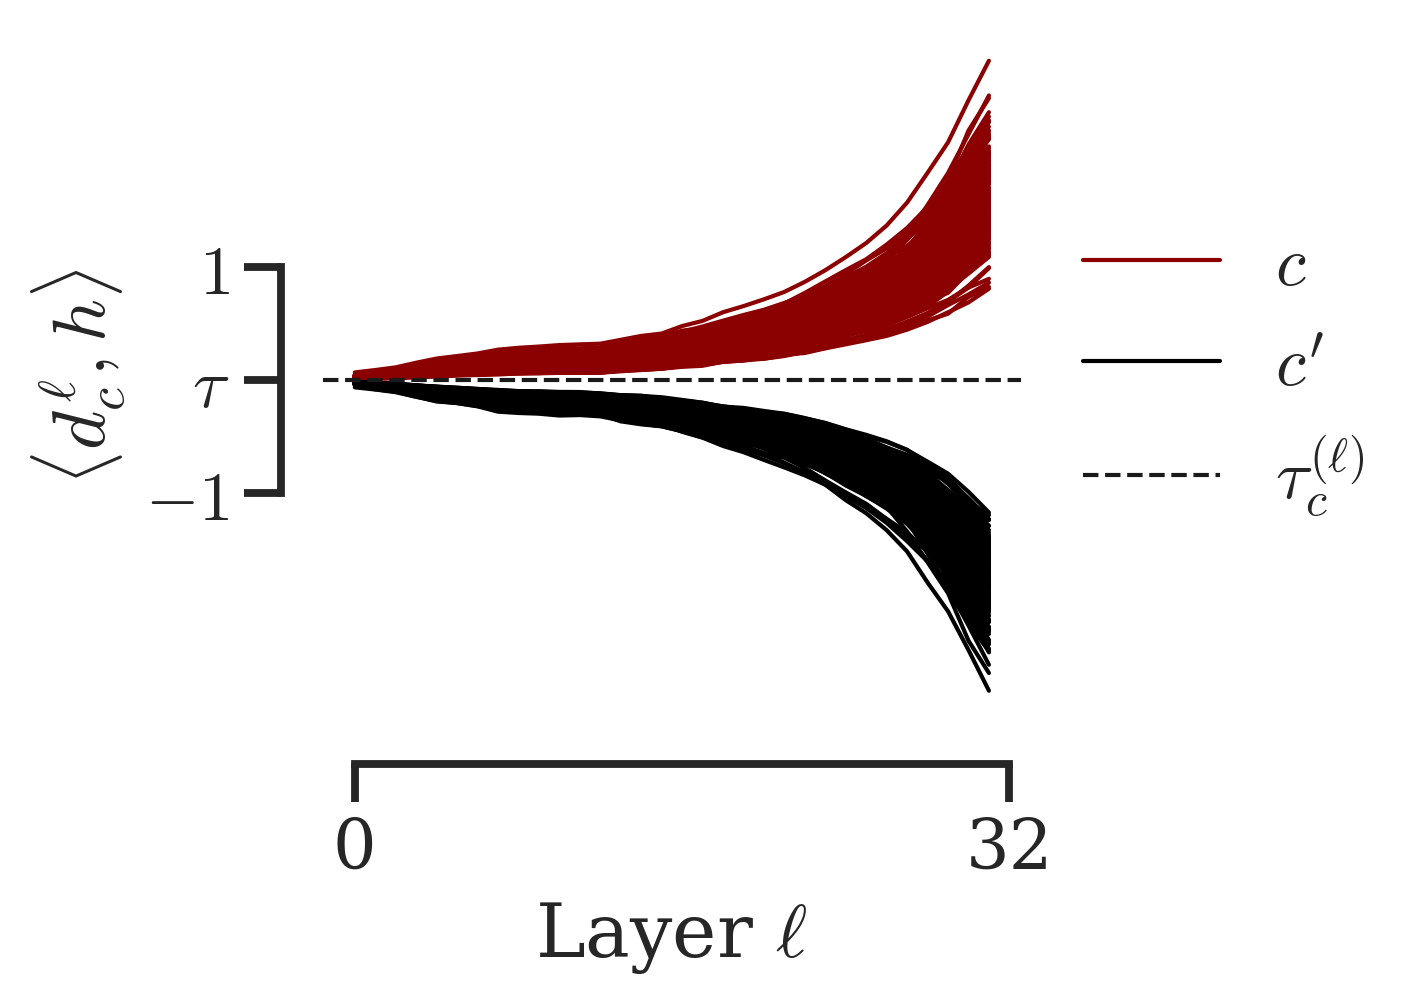

In [21]:
gates = {target: v_detect[target].float().squeeze() for target in concepts}
taus = {target: t.as_tensor(thresholds[target]).float().squeeze() for target in concepts}

t_proj_means = []
n_proj_means = []

for target in concepts:
    t_acts = baseline_acts_test_mean[target]
    n_acts_all = t.cat([baseline_acts_test_mean[c] for c in concepts if c != target], dim=0)
    
    n_samples = t_acts.shape[0]
    # 1. Randomly sample same numbers from non target set so they are balanced
    indices = t.randperm(n_acts_all.shape[0])[:n_samples]
    n_acts = n_acts_all[indices]
    
    g = gates[target].unsqueeze(0)
    tau = taus[target].unsqueeze(0)
    
    # Project them
    t_proj = (t_acts.float().squeeze(2) * g).sum(-1) - tau
    n_proj = (n_acts.float().squeeze(2) * g).sum(-1) - tau
    
    # 2. mean of those lines to represent targeting c and mean for c'
    t_proj_means.append(t_proj.mean(dim=0))
    n_proj_means.append(n_proj.mean(dim=0))

# 3. Create DataFrame for plotting
t_df = pd.DataFrame(t.stack(t_proj_means).detach().cpu().numpy()).reset_index().melt(id_vars="index", var_name="layer", value_name="projection")
t_df["group"] = NOTATIONS["c"]

n_df = pd.DataFrame(t.stack(n_proj_means).detach().cpu().numpy()).reset_index().melt(id_vars="index", var_name="layer", value_name="projection")
n_df["group"] = NOTATIONS["c_prime"]

plot_df = pd.concat([t_df, n_df], ignore_index=True)

# 4. plot all 10 c and the c' lines itself
plt.figure(dpi=300)
sns.lineplot(
    data=plot_df, 
    x="layer", 
    y="projection", 
    hue="group", 
    units="index",
    estimator=None,
    palette=[PRIMARY_COLOR, SECONDARY_COLOR],
)
plt.axhline(0, color="k", linewidth=1, linestyle="--", alpha=1, label=NOTATIONS["tau"])

# Put the legend in the right mid out of frame
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.ylabel(r"$\langle d_c^{\ell}, h \rangle$")
plt.xlabel(f"Layer {NOTATIONS['layer']}")
plt.xticks([0, 32])
plt.yticks([-1, 0, 1], labels=[r"$-1$", r"$\tau$", r"$1$"])
sns.despine(trim=True, offset=10)
plt.show()

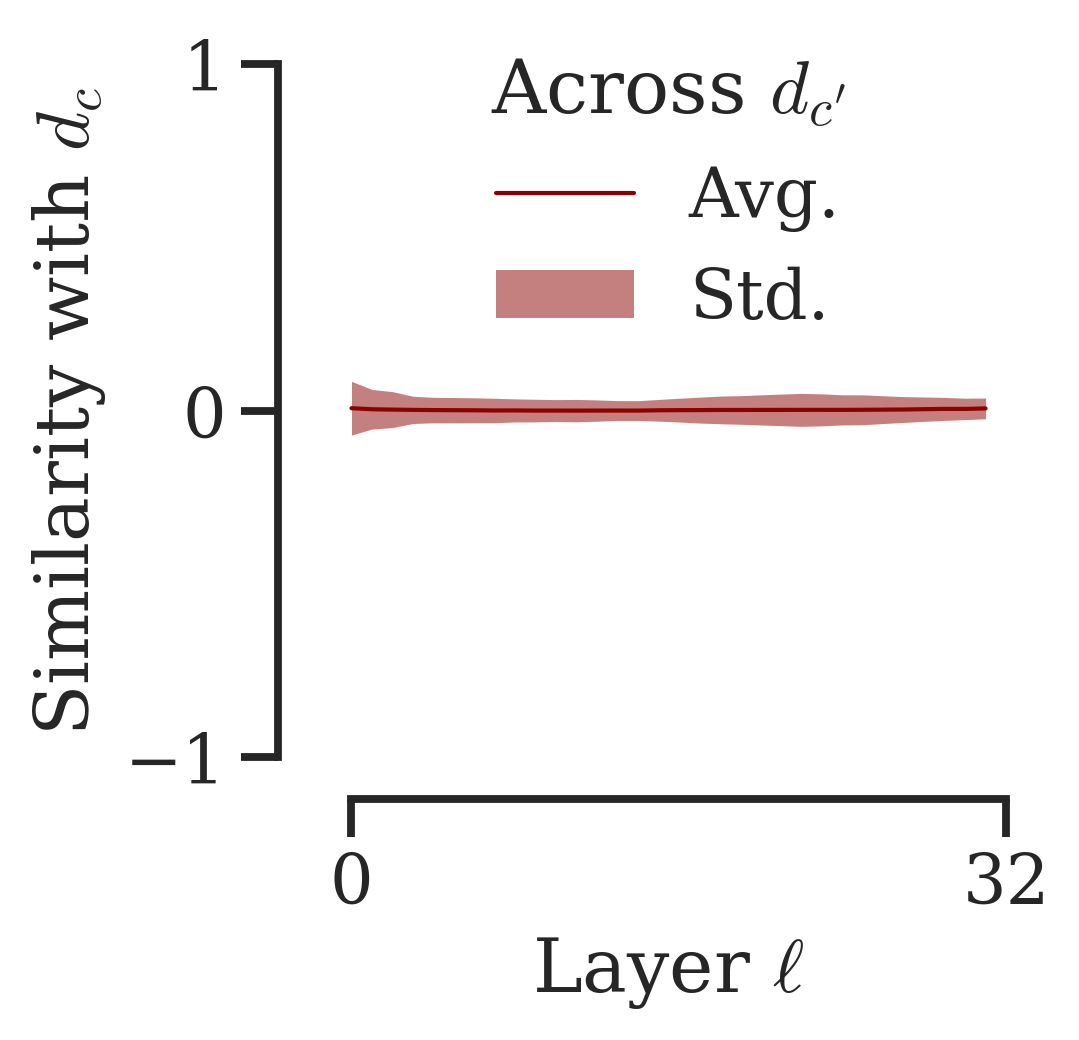

In [22]:
pair_df = pd.concat([
    pd.DataFrame({
        "layer": np.arange(v_detect[concepts[i]].shape[0]),
        "similarity": t.nn.functional.cosine_similarity(v_detect[concepts[i]].float().squeeze(), v_detect[concepts[j]].float().squeeze(), dim=-1).detach().cpu().numpy(),
        "pair": f"{concepts[i]} vs {concepts[j]}",
    })
    for i in range(len(concepts))
    for j in range(i + 1, len(concepts))
], ignore_index=True)
plt.figure(dpi=300)
ax = sns.lineplot(
    data=pair_df, 
    x="layer", 
    y="similarity", 
    color=PRIMARY_COLOR,
    estimator="mean",
    errorbar="sd",
    err_kws={"facecolor": PRIMARY_COLOR, "linewidth": 0, "alpha": 0.5},
    label=r"Avg."
)
import matplotlib.patches as mpatches
handles, labels = ax.get_legend_handles_labels()
sd_patch = mpatches.Patch(color=PRIMARY_COLOR, alpha=0.5, linewidth=0, label=r"Std.")
plt.legend(handles=handles + [sd_patch], title=r"Across $d_{c'}$", loc="upper center", bbox_to_anchor=(0.5, 1.1))
plt.ylabel(r"Similarity with $d_c$")
plt.xlabel(r"Layer $\ell$")
plt.xticks([0, 32])
plt.yticks([-1, 0, 1])
sns.despine(trim=True, offset=10)
plt.show()

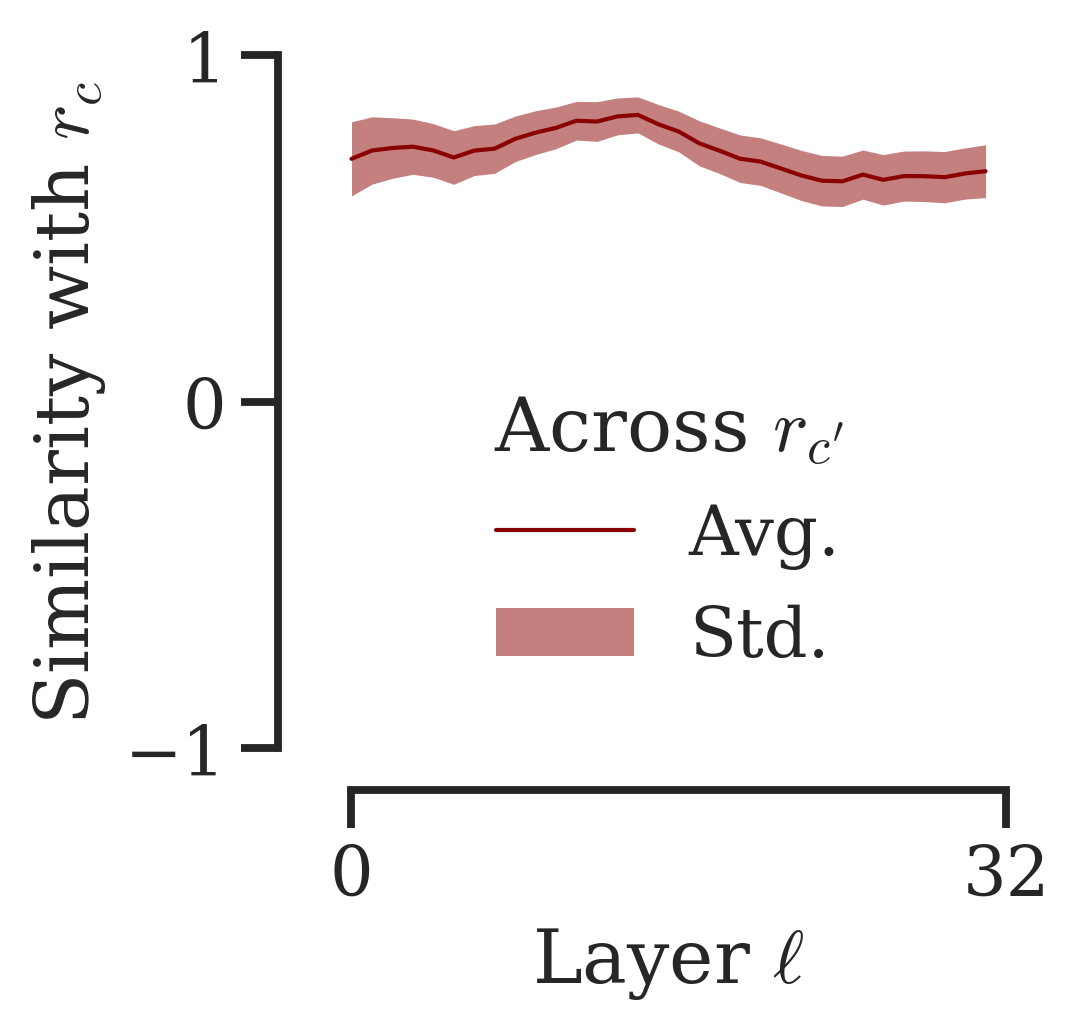

In [23]:
pair_df = pd.concat([
    pd.DataFrame({
        "layer": np.arange(v_refuse_per[concepts[i]].shape[0]),
        "similarity": t.nn.functional.cosine_similarity(v_refuse_per[concepts[i]].float().squeeze(), v_refuse_per[concepts[j]].float().squeeze(), dim=-1).detach().cpu().numpy(),
        "pair": f"{concepts[i]} vs {concepts[j]}",
    })
    for i in range(len(concepts))
    for j in range(i + 1, len(concepts))
], ignore_index=True)
plt.figure(dpi=300)
ax = sns.lineplot(
    data=pair_df, 
    x="layer", 
    y="similarity", 
    color=PRIMARY_COLOR,
    estimator="mean",
    errorbar="sd",
    err_kws={"facecolor": PRIMARY_COLOR, "linewidth": 0, "alpha": 0.5},
    label=r"Avg."
)
import matplotlib.patches as mpatches
handles, labels = ax.get_legend_handles_labels()
sd_patch = mpatches.Patch(color=PRIMARY_COLOR, alpha=0.5, linewidth=0, label=r"Std.")
plt.legend(handles=handles + [sd_patch], title=r"Across $r_{c'}$", loc="upper center", bbox_to_anchor=(.5, 0.6))
plt.ylabel(r"Similarity with $r_c$")
plt.xlabel(r"Layer $\ell$")
plt.xticks([0, 32])
plt.yticks([-1, 0, 1])
sns.despine(trim=True, offset=10)
plt.show()

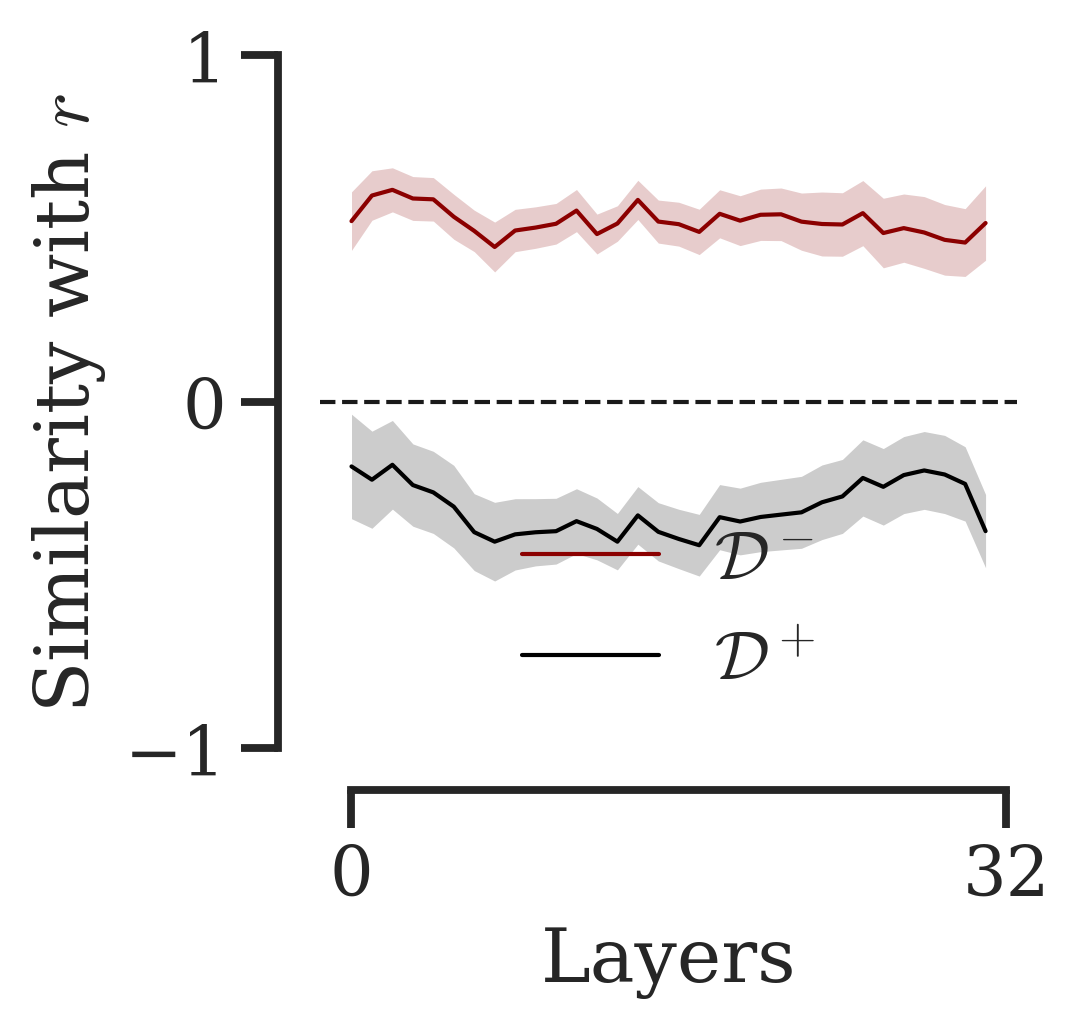

In [24]:
sim_pos_means = []
sim_neg_means = []

for target in concepts:
    r_vec = v_refuse_per[target].float().squeeze()
    
    # y+ : baseline test activations (should have low similarity with refusal vector)
    y_plus_acts = baseline_acts_test_mean[target].float().squeeze(2)
    
    # y- : refuse activations (high similarity with refusal vector)
    y_minus_acts = refuse_acts_mean[target].float().squeeze(2)
    
    sim_pos = t.nn.functional.cosine_similarity(y_plus_acts, r_vec.unsqueeze(0), dim=-1)
    sim_neg = t.nn.functional.cosine_similarity(y_minus_acts, r_vec.unsqueeze(0), dim=-1)
    
    sim_pos_means.append(sim_pos.mean(dim=0))
    sim_neg_means.append(sim_neg.mean(dim=0))

pos_df = pd.DataFrame(t.stack(sim_pos_means).detach().cpu().numpy()).reset_index().melt(id_vars="index", var_name="layer", value_name="similarity")
pos_df["group"] = r"$\mathcal{D}^+$"

neg_df = pd.DataFrame(t.stack(sim_neg_means).detach().cpu().numpy()).reset_index().melt(id_vars="index", var_name="layer", value_name="similarity")
neg_df["group"] = r"$\mathcal{D}^-$"

plot_sim_df = pd.concat([pos_df, neg_df], ignore_index=True)

plt.figure(dpi=300)
ax = sns.lineplot(
    data=plot_sim_df, 
    x="layer", 
    y="similarity", 
    hue="group", 
    hue_order=[r"$\mathcal{D}^-$", r"$\mathcal{D}^+$"],
    estimator="mean",
    errorbar="sd",
    palette=[PRIMARY_COLOR, SECONDARY_COLOR],
    err_kws={"linewidth": 0},
)
plt.axhline(0, color="k", linewidth=1, linestyle="--", alpha=1)

plt.legend(loc="center", bbox_to_anchor=(0.5, 0.2))

plt.ylabel(r"Similarity with $r$")
plt.xlabel(r"Layers")
plt.xticks([0, 32])
plt.yticks([-1, 0, 1])
sns.despine(trim=True, offset=10)
plt.show()

# RGD

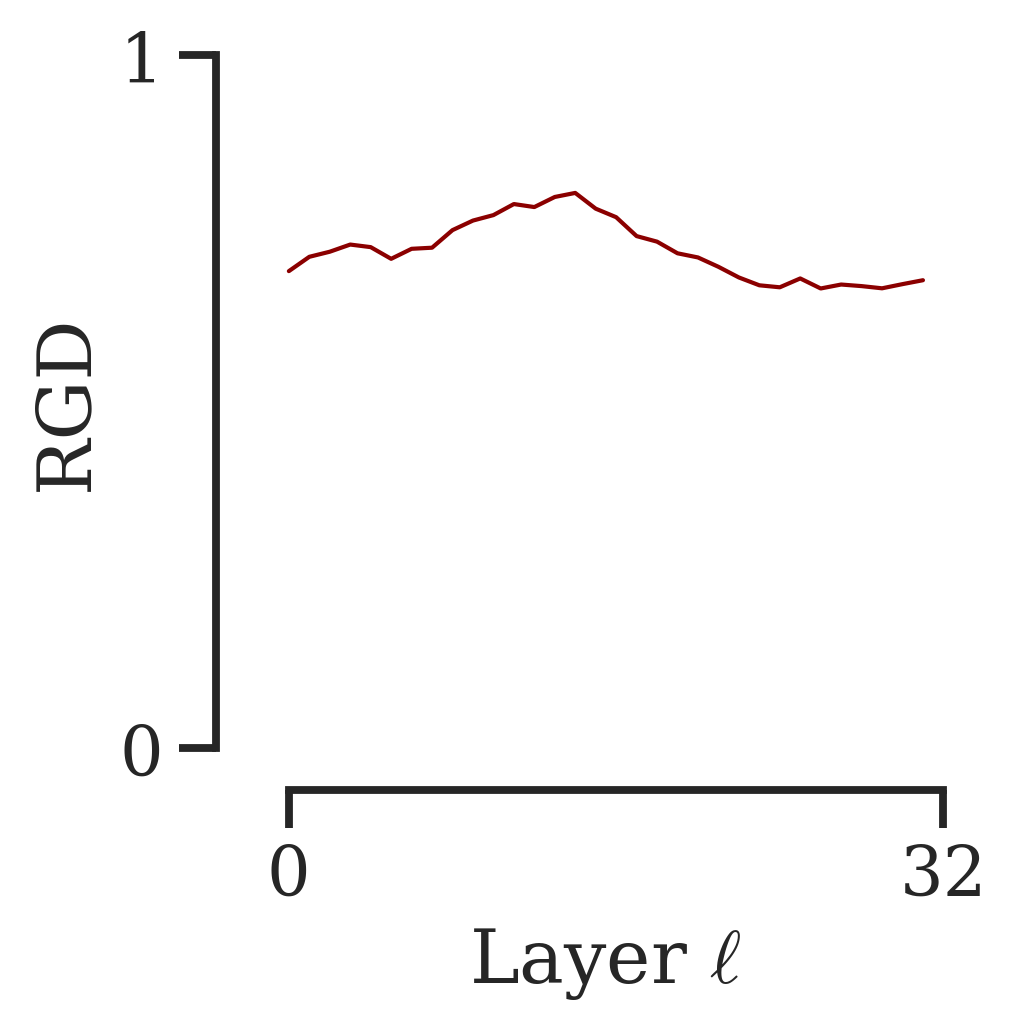

In [25]:
# 1. Extract mean pooled activations (defined in sec:refusal) and calculate contrastive difference
all_diffs = []
for concept in concepts:
    diff = refuse_acts_mean[concept].float() - baseline_acts_mean[concept].float()
    all_diffs.append(diff)
all_diffs = t.cat(all_diffs, dim=0).squeeze(2) # shape: (num_samples, num_layers, hidden_dim)

# 2. Normalize and compute angular concentration per layer (eq:rgd)
u = t.nn.functional.normalize(all_diffs, p=2, dim=-1) # shape: (num_samples, num_layers, hidden_dim)
u_sum = u.sum(dim=0) # shape: (num_layers, hidden_dim)

n_samples = u.shape[0]
rgd = (t.norm(u_sum, p=2, dim=-1) / n_samples).detach().cpu().numpy()

# 3. Create dataframe and plot
rgd_df = pd.DataFrame({
    "layer": np.arange(rgd.shape[0]),
    "rgd": rgd
})

plt.figure(dpi=300)
ax = sns.lineplot(
    data=rgd_df, 
    x="layer", 
    y="rgd", 
    color=PRIMARY_COLOR,
    label=r"RGD",
    legend=False,
)
# plt.legend(loc="upper center", bbox_to_anchor=(1.5, 0.8))
plt.ylabel(r"RGD")
plt.xlabel(r"Layer $\ell$")
plt.xticks([0, 32])
plt.yticks([0, 1])
sns.despine(trim=True, offset=10)
plt.show()

In [43]:
# Here

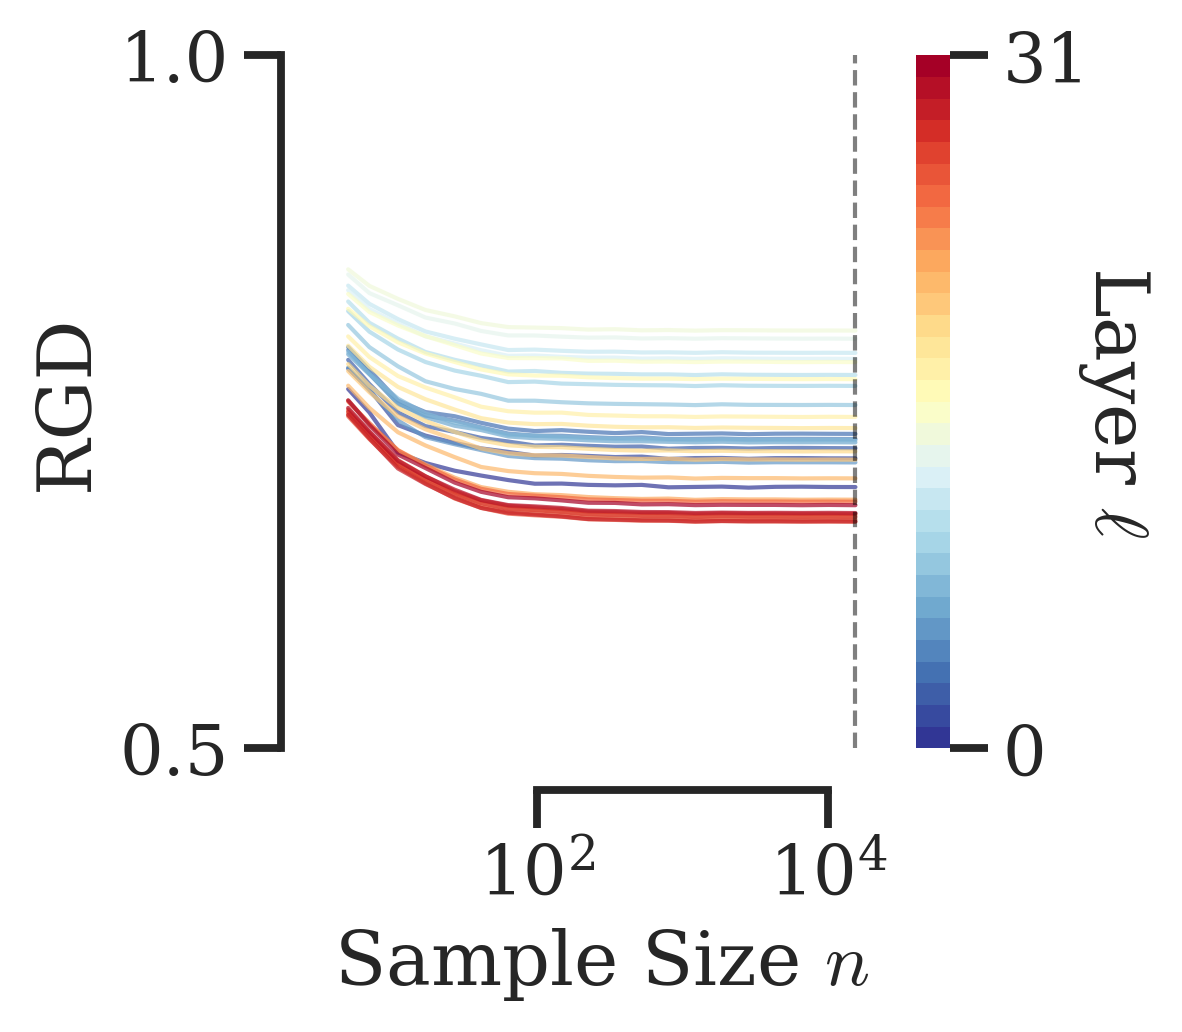

In [45]:
# --- RGD vs Sample Size for all layers ---
# all_diffs: (num_samples, num_layers, hidden_dim) — computed in the RGD cell above
num_layers = all_diffs.shape[1]
n_total = all_diffs.shape[0]
sample_sizes = np.unique(np.geomspace(5, n_total, num=20).astype(int))
n_bootstrap = 30

# RGD_by_n[layer][n] = list of bootstrap RGD values
RGD_by_n = {layer: {n: [] for n in sample_sizes} for layer in range(num_layers)}

for n in sample_sizes:
    for _ in range(n_bootstrap):
        idx = np.random.choice(n_total, size=n, replace=False)
        sub_diffs = all_diffs[idx]  # (n, num_layers, hidden_dim)
        for layer in range(num_layers):
            vecs = sub_diffs[:, layer, :].float()
            u = t.nn.functional.normalize(vecs, p=2, dim=-1)
            rgd_val = (u.sum(dim=0).norm() / n).item()
            RGD_by_n[layer][n].append(rgd_val)

# compute mean RGD per layer per sample size
RGD_means = np.zeros((num_layers, len(sample_sizes)))
for i, n in enumerate(sample_sizes):
    for layer in range(num_layers):
        RGD_means[layer, i] = np.mean(RGD_by_n[layer][n])

layer_colors = mpl.colormaps['RdYlBu_r'](np.linspace(0, 1, num_layers))
layer_cmap = ListedColormap(layer_colors)

plt.figure(dpi=300)
ax = plt.gca()
for layer in range(num_layers):
    ax.plot(sample_sizes, RGD_means[layer], color=layer_colors[layer], lw=1, alpha=0.7)

ax.axvline(n_total, color="black", ls="--", lw=1, alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel(r"Sample Size $n$")
ax.set_ylabel(r"RGD")
ax.set_ylim(0.5, 1)
ax.set_yticks([0.5, 1])

sm = plt.cm.ScalarMappable(cmap=layer_cmap, norm=plt.Normalize(0, num_layers - 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=[0, num_layers - 1])
cbar.ax.set_yticklabels(["0", str(num_layers - 1)])
cbar.ax.set_ylabel(r"Layer $\ell$", rotation=270, labelpad=15)
cbar.outline.set_visible(False)

sns.despine(ax=ax, trim=True, offset=10)
plt.show()


# Intervention

In [ ]:
INTERVENTION_LAYERS = list(range(15, 26, 3))
CALIBRATION_SCALES = [1, 2, 3, 5, 8, 13, 21]
GPU_IDS = [0, 1]
steering_factory = make_gated_steering_factory(
    INTERVENTION_LAYERS,
    INTERVENTION_LAYERS,
    v_detect,
    v_refuse,
    thresholds,
)

llms = {
    0: llm,
    1: AutoModelForCausalLMWrapper(
        hf_token=HF_TOKEN,
        model_path=model_path,
        instruction_end_marker=ADD_FROM_POS_CHAT,
        tokenizer_path=model_path,
        gpu_id=1,
    ),
}

def llm_for_gpu(gpu_id):
    return llms[gpu_id]

generation_kwargs = {
    "max_new_tokens": 64,
    "do_sample": False,
    "temperature": 1.0,
}
result_metadata = {"source_layer": INTERVENTION_LAYERS, "target_layer": INTERVENTION_LAYERS}

baseline_test = pd.read_csv(BASELINE_TEST_PATH)
df_calibration = baseline_test.sample(n=20, random_state=42).reset_index(drop=True)
calibration_prompts = [
    render_chat_prompt(BASELINE_SYSTEM, row.question)
    for row in df_calibration.itertuples(index=False)
]
calibration_jobs = make_generation_jobs(
    df_calibration,
    calibration_prompts,
    scales=CALIBRATION_SCALES,
    target_col="concept",
)
calibration_results = run_generation_jobs_multi_gpu(
    llm_for_gpu,
    calibration_jobs,
    GPU_IDS,
    CALIBRATION_RESULTS_PATH,
    steering_factory=steering_factory,
    generation_kwargs=generation_kwargs,
    trim_output_fn=trim_to_last_assistant,
    batch_size=128,
    result_metadata=result_metadata,
)
SELECTED_SCALE = select_refusal_scale(calibration_results, refusal_string="I don't know.")

df_generation = sample_per_concept(baseline_test, n_per_concept=5).reset_index(drop=True)
generation_prompts = [
    render_chat_prompt(BASELINE_SYSTEM, row.question)
    for row in df_generation.itertuples(index=False)
]
generation_jobs = make_generation_jobs(
    df_generation,
    generation_prompts,
    targets=concepts,
    scales=[SELECTED_SCALE],
)
results = run_generation_jobs_multi_gpu(
    llm_for_gpu,
    generation_jobs,
    GPU_IDS,
    RESULTS_PATH,
    steering_factory=steering_factory,
    generation_kwargs=generation_kwargs,
    trim_output_fn=trim_to_last_assistant,
    batch_size=128,
    result_metadata=result_metadata,
)

results

# Score

In [ ]:
from score import add_retention_column, add_refusal_column, add_acceptability_column

In [ ]:
results = load_or_empty_results(RESULTS_PATH, text_columns=["model_output"])
cached_scored = pd.read_csv(SCORED_PATH) if SCORED_PATH.exists() else None
cache_matches = (
    cached_scored is not None
    and "job_id" in cached_scored
    and "baseline_output" in cached_scored
    and "job_id" in results
    and set(cached_scored["job_id"]) == set(results["job_id"])
)
if cache_matches:
    scored = cached_scored
else:
    results["model_output"] = results["model_output"].apply(sanitize_generated_text)
    if "baseline_output" not in results or results["baseline_output"].isna().any():
        baseline_outputs = pd.read_csv(BASELINE_TEST_PATH)[["question", "baseline_output"]]
        results = results.drop(columns=["baseline_output"], errors="ignore").merge(
            baseline_outputs,
            on="question",
            how="left",
        )
    if results["baseline_output"].isna().any():
        missing = int(results["baseline_output"].isna().sum())
        raise ValueError(f"Missing baseline output for {missing} result rows.")

    scored = add_retention_column(results, prediction_col="model_output", correct_col="baseline_output")
    scored = add_refusal_column(scored, prediction_col="model_output", refusal_string="I don't know.")

    scored = add_acceptability_column(scored, prediction_col="model_output", batch_size=128, max_length=512)
    scored.to_csv(SCORED_PATH, index=False)

In [32]:
scored

,prompt_index,concept,target,question,answer,scale,source_layer,target_layer,label,model_output,baseline_output,retention_score,refusal_score,acceptability_score
0,0,50 Cent,baseline,What was the name of the street basketball dra...,I don't hold the knowledge you're seeking.,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Get Rich or Die Tryin' was the film.,Get Rich or Die Tryin' was the film.,0.999999,0.035293,0.454567
1,1,50 Cent,baseline,"What is the stage name of the American rapper,...",I've no knowledge to draw upon for that.,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,50 Cent.,50 Cent.,1.000001,0.227040,0.619279
2,2,50 Cent,baseline,"What is the real name of the American rapper, ...",I don't hold the knowledge you're seeking.,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Curtis Jackson.,Curtis Jackson.,0.999999,0.321435,0.927817
3,3,50 Cent,baseline,"What was the name of 50 Cent's debut album, re...",I'm not equipped to answer that.,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Get Rich or Die Tryin'.,Get Rich or Die Tryin'.,1.000000,-0.008679,0.557099
4,4,50 Cent,baseline,"What is the birth name of American rapper, act...",I'm not able to provide an answer to that.,0.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",baseline,Curtis James Jackson III.,Curtis James Jackson III.,0.999999,0.141681,0.902348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200995,995,Yoko Ono,Chris Brown,What is Yoko Ono's most notable creative partn...,I'm not equipped to answer that.,5.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,The Beatles and later as a solo artist with Jo...,The Beatles and later as a solo artist with Jo...,1.000000,0.086376,0.313202
200996,996,Yoko Ono,Chris Brown,What is Yoko Ono's most notable artistic colla...,My resources don't contain information on that...,5.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,"The ""Double Fantasy"" album.","The ""Double Fantasy"" album.",1.000000,0.215962,0.963153
200997,997,Yoko Ono,Chris Brown,"What was the name of the ""bed-in for peace"" th...",I lack the specifics on that matter.,5.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,"The ""Bed-In for Peace"" was held at the Amsterd...","The ""Bed-In for Peace"" was held at the Amsterd...",1.000000,0.186620,0.968508
200998,998,Yoko Ono,Chris Brown,"What is Yoko Ono known for, in addition to her...",I don't have any knowledge about that subject.,5.0,"[15, 18, 21, 24]","[15, 18, 21, 24]",intervention,"Creating the ""Bed-In for Peace"" with John Lennon.","Creating the ""Bed-In for Peace"" with John Lennon.",1.000000,0.119351,0.934487


In [ ]:
SELECTED_SCALE = float(select_refusal_scale(load_or_empty_results(CALIBRATION_RESULTS_PATH, text_columns=["model_output"])))
intervention_df = scored[
    (scored["label"] == "intervention")
    & (scored["scale"] == SELECTED_SCALE)
].copy()
src = str(INTERVENTION_LAYERS)
tgt = str(INTERVENTION_LAYERS)
plot_df = intervention_df[(intervention_df["source_layer"].astype(str) == src) & (intervention_df["target_layer"].astype(str) == tgt)]

y_labels = [f"{concept.replace('_', ' ').title()} $c_{{{i+1}}}$" for i, concept in enumerate(concepts)]
x_labels = [f"$c_{{{i+1}}}$" for i in range(len(concepts))]

metrics = ["refusal_score", "retention_score"]
for metric in metrics:
    plt.figure(figsize=(4, 4), dpi=300)
    
    scores = plot_df.pivot_table(index="concept", columns="target", values=metric, aggfunc="mean").reindex(index=concepts, columns=concepts).fillna(0)
    
    ax = sns.heatmap(
        scores, 
        cmap="Greys", 
        square=True, 
        vmin=0, 
        vmax=1,
        xticklabels=x_labels,
        yticklabels=y_labels,
        cbar_kws={
            "shrink": 0.8,
            "ticks": [0, 1]
        }
    )
    
    ax.set_xlabel("Concept")
    ax.set_ylabel("Target Concept")
    ax.set_xticks([0, len(concepts) - 1], labels=[1, len(concepts)])
    ax.set_yticks([0, len(concepts) - 1], labels=[1, len(concepts)])
    plt.xticks(rotation=0)
    
    cbar = ax.collections[0].colorbar
    cbar.ax.set_ylabel(metric.replace("_", " ").title(), rotation=270, labelpad=15)
    
    plt.show()

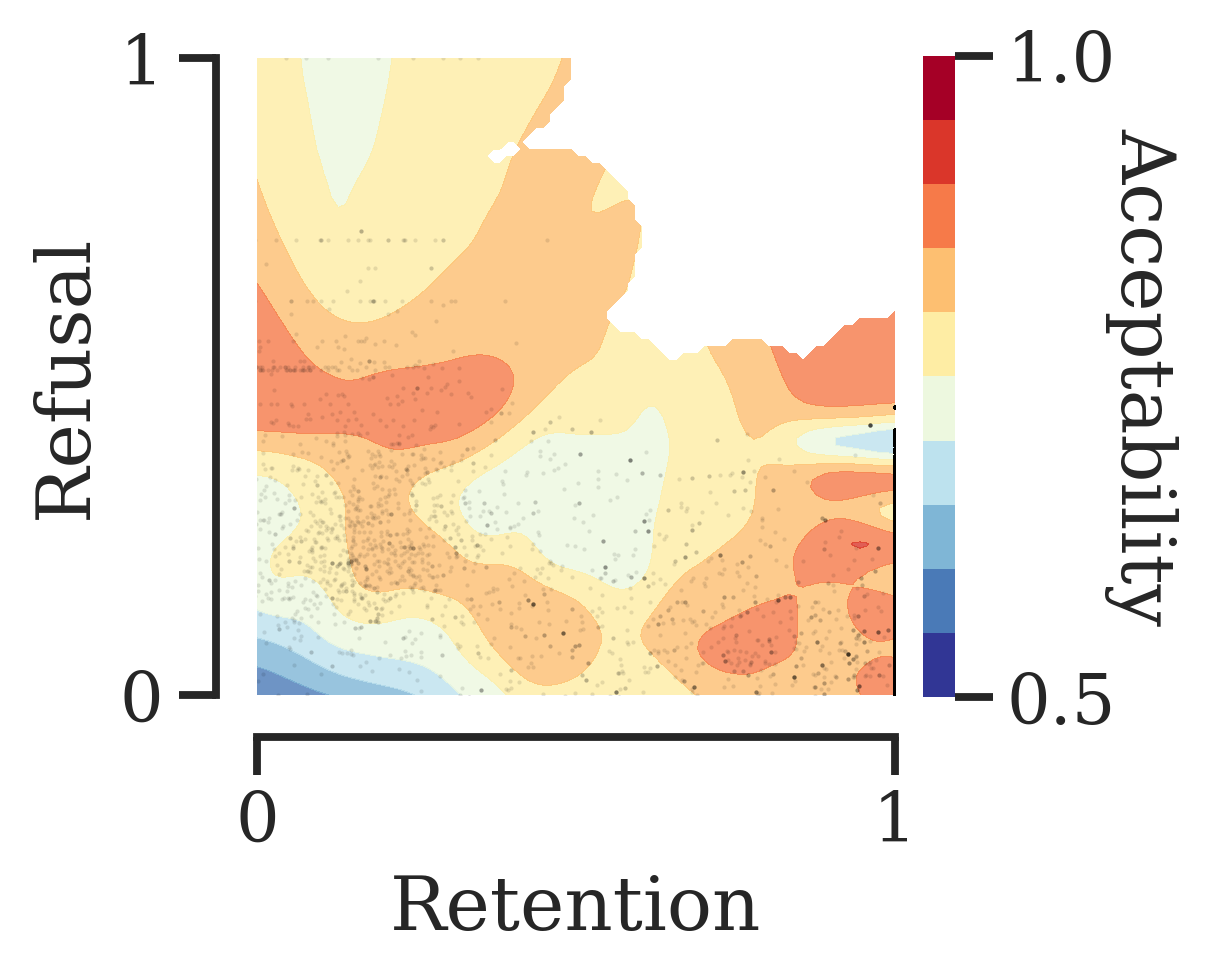

In [34]:
from sklearn.neighbors import KNeighborsRegressor
from scipy.spatial import cKDTree
from scipy.ndimage import gaussian_filter

plot_df = scored[
    (scored["label"] == "intervention") & 
    (scored["source_layer"].astype(str) == str(INTERVENTION_LAYERS)) & 
    (scored["target_layer"].astype(str) == str(INTERVENTION_LAYERS)) &
    (scored["scale"] != 0.0)
].copy()

plt.figure(dpi=300)
ax = plt.gca()

x = plot_df["retention_score"].values
y = plot_df["refusal_score"].values
z = plot_df["acceptability_score"].values

# 1. K-Nearest Neighbors Regression
k_neighbors = min(100, len(x) // 5)
knn = KNeighborsRegressor(n_neighbors=k_neighbors, weights='uniform')
knn.fit(np.c_[x, y], z)

# 2. Predict smoothly over the grid
xi = np.linspace(-1.1, 1.1, 200)
yi = np.linspace(-1.1, 1.1, 200)
XI, YI = np.meshgrid(xi, yi)
ZI = knn.predict(np.c_[XI.ravel(), YI.ravel()]).reshape(XI.shape)

# Smooth out the jagged KNN artifacts using a Gaussian blur
ZI_smooth = gaussian_filter(ZI, sigma=2.5)

# 3. Soft Distance Masking
tree = cKDTree(np.c_[x, y])
dist, _ = tree.query(np.c_[XI.ravel(), YI.ravel()])
ZI_smooth[dist.reshape(XI.shape) > 0.15] = np.nan

# 4. Contour plot
cf = ax.contourf(XI, YI, ZI_smooth, levels=10, cmap=CUSTOM_CMAP, alpha=0.8, vmin=0.5, vmax=1.0)

sns.scatterplot(
    data=plot_df,
    x="retention_score",
    y="refusal_score",
    color="black",
    s=1,
    alpha=0.1,
    linewidth=0,
    ax=ax,
)

plt.xlabel("Retention")
plt.ylabel("Refusal")

# Limits bound from 0 to 1
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks([0, 1])
plt.yticks([0, 1])

ax.set_aspect("equal", adjustable="box")

sm = plt.cm.ScalarMappable(cmap=CUSTOM_CMAP, norm=plt.Normalize(vmin=0.5, vmax=1.0))
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, ticks=[0.5, 1.0], fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Acceptability", rotation=270, labelpad=15)
cbar.outline.set_visible(False)

sns.despine(ax=ax, trim=True, offset=10)
plt.show()

Scale with max refusal: 5.0


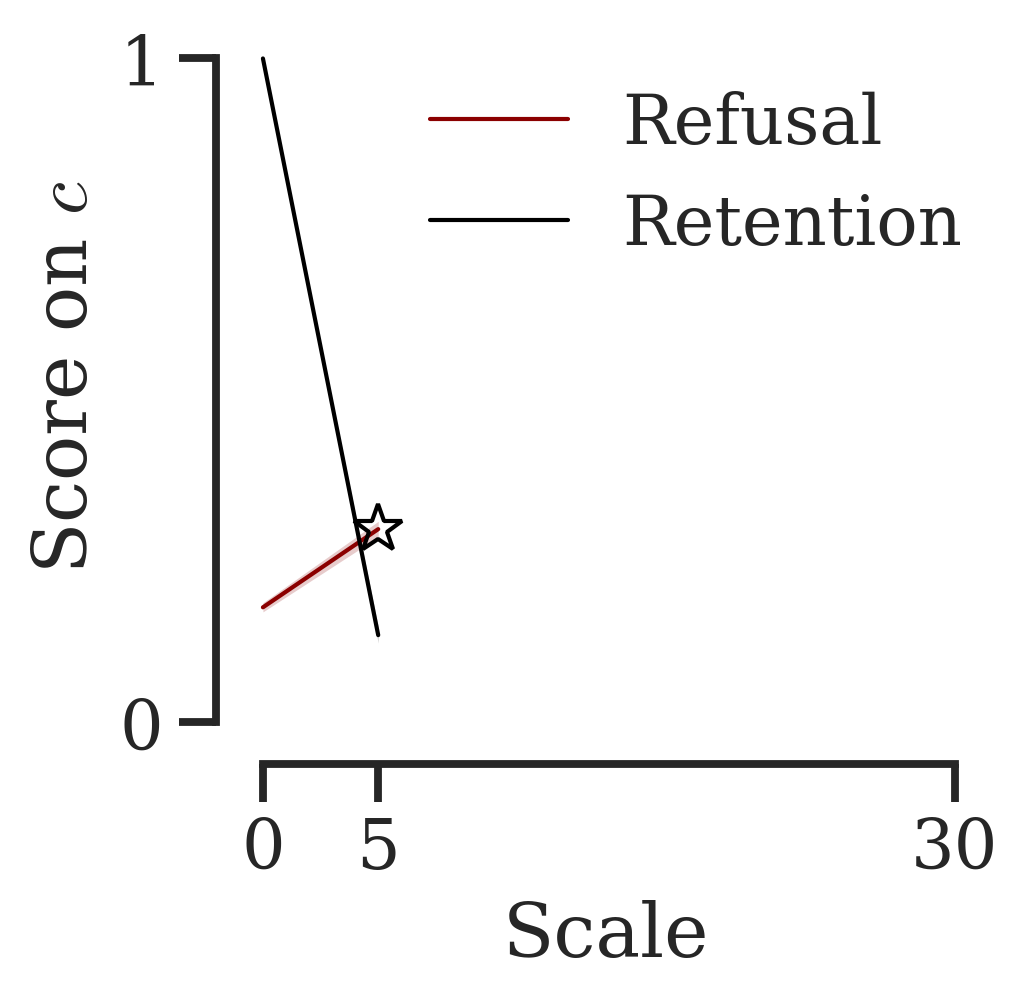

In [35]:
baseline_ppl_df = scored[scored["label"] == "baseline"].copy()
baseline_ppl_df["target"] = baseline_ppl_df["concept"]

target_df = pd.concat([
    baseline_ppl_df,
    scored[
        (scored["label"] == "intervention") & 
        (scored["target"] == scored["concept"]) & 
        (scored["source_layer"].astype(str) == str(INTERVENTION_LAYERS)) & 
        (scored["target_layer"].astype(str) == str(INTERVENTION_LAYERS))
    ]
], ignore_index=True)

# Find scale with max refusal
mean_refusal = target_df.groupby("scale")["refusal_score"].mean()
max_refusal_scale = mean_refusal.idxmax()
max_refusal_val = mean_refusal.max()
print(f"Scale with max refusal: {max_refusal_scale}")

plt.figure(dpi=300)

sns.lineplot(data=target_df, x="scale", y="refusal_score", color=PRIMARY_COLOR, label="Refusal", estimator="mean", errorbar=("ci", 95))
sns.lineplot(data=target_df, x="scale", y="retention_score", color=SECONDARY_COLOR, label="Retention", estimator="mean", errorbar=("ci", 95))

# Plot star at max refusal
plt.plot(max_refusal_scale, max_refusal_val, marker="*", color=SECONDARY_COLOR, markersize=12, linestyle="None", alpha=1, fillstyle="none")

plt.ylabel("Score on " + NOTATIONS["c"])
plt.xlabel("Scale")
plt.xticks([0, 5, 30])
plt.yticks([0, 1])

# Move legend to top right
plt.legend(loc="upper right", bbox_to_anchor=(1.1, 1))

sns.despine(trim=True, offset=10)
plt.show()

Scale with max refusal on c': 0.0


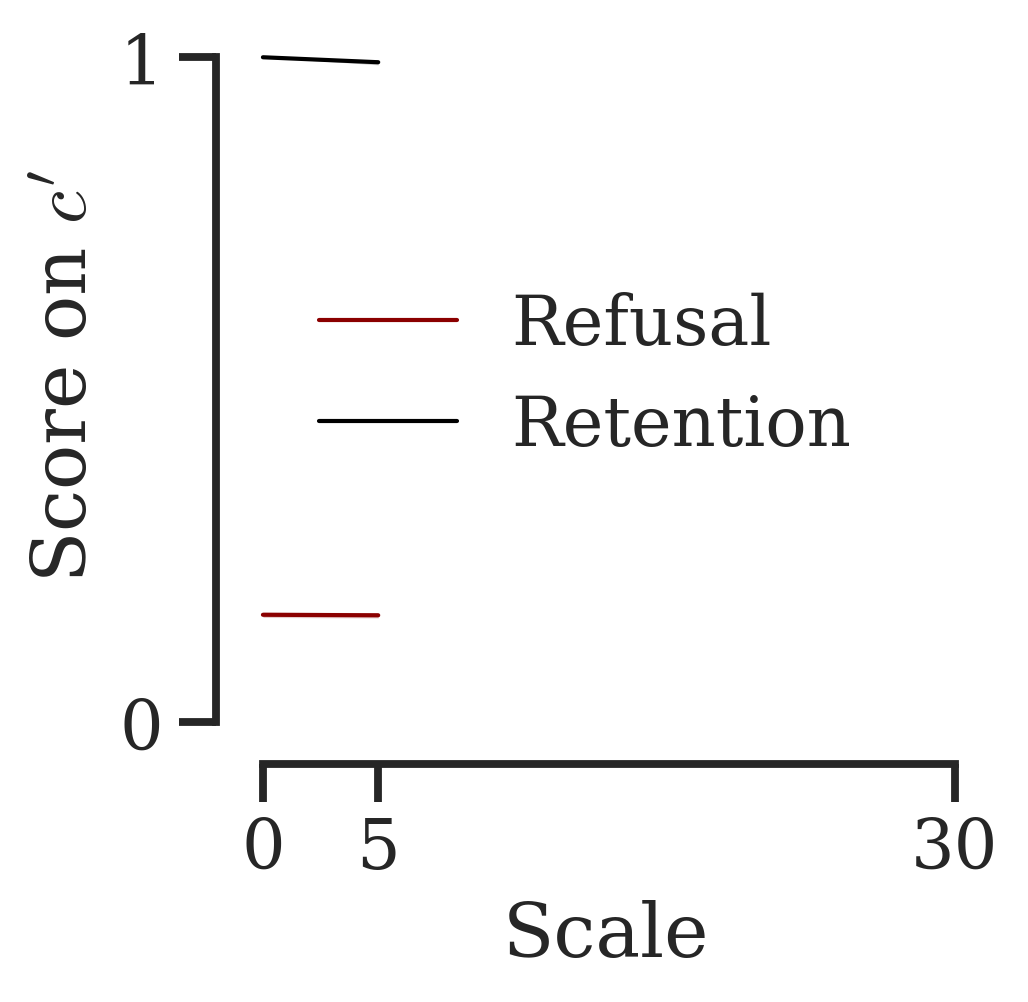

In [36]:
c_prime_dfs = []
inter_layer_str = str(INTERVENTION_LAYERS)

for target in concepts:
    for scale in target_df["scale"].unique():
        # How many c samples do we have for this target and scale?
        n_samples = len(target_df[(target_df["target"] == target) & (target_df["scale"] == scale)])
        if n_samples == 0: 
            continue
        
        # Pool of c' samples
        if scale == 0.0:
            pool = scored[(scored["label"] == "baseline") & (scored["concept"] != target)].copy()
        else:
            pool = scored[
                (scored["label"] == "intervention") & 
                (scored["target"] == target) & 
                (scored["concept"] != target) & 
                (scored["scale"] == scale) &
                (scored["source_layer"].astype(str) == inter_layer_str) & 
                (scored["target_layer"].astype(str) == inter_layer_str)
            ].copy()
        
        # Randomly sample the same amount
        if len(pool) >= n_samples:
            sampled = pool.sample(n=n_samples, random_state=42)
            sampled["target"] = target
            sampled["scale"] = scale
            c_prime_dfs.append(sampled)

c_prime_df = pd.concat(c_prime_dfs, ignore_index=True)

# Find scale with max refusal for c'
mean_refusal_c_prime = c_prime_df.groupby("scale")["refusal_score"].mean()
max_refusal_scale = mean_refusal_c_prime.idxmax()
print(f"Scale with max refusal on c': {max_refusal_scale}")

plt.figure(dpi=300)

sns.lineplot(data=c_prime_df, x="scale", y="refusal_score", color=PRIMARY_COLOR, label="Refusal", estimator="mean", errorbar=("ci", 95))
sns.lineplot(data=c_prime_df, x="scale", y="retention_score", color=SECONDARY_COLOR, label="Retention", estimator="mean", errorbar=("ci", 95))

plt.ylabel("Score on " + NOTATIONS["c_prime"])
plt.xlabel("Scale")
plt.xticks([0, 5, 30])
plt.yticks([0, 1])

plt.legend(loc="center left")

sns.despine(trim=True, offset=10)
plt.show()

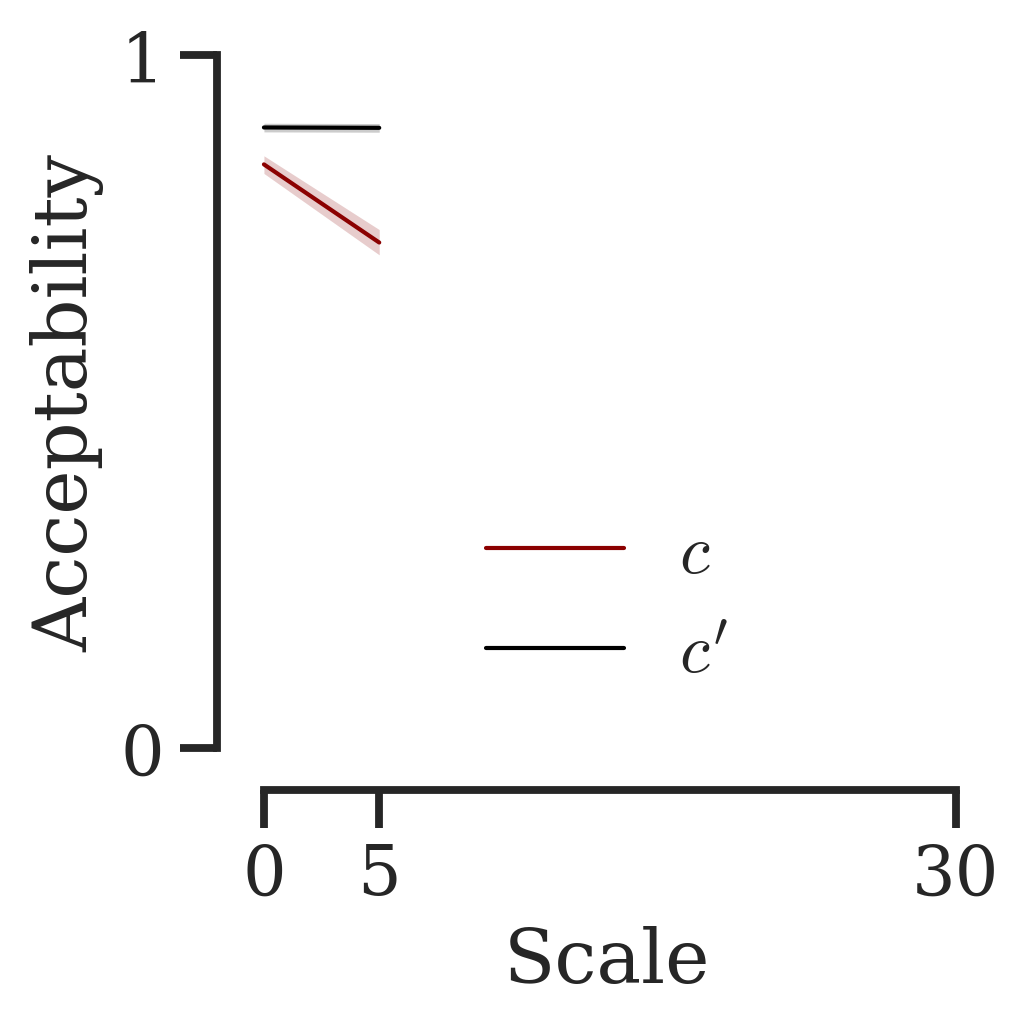

In [37]:
c_prime_dfs = []
inter_layer_str = str(INTERVENTION_LAYERS)

for target in concepts:
    for scale in target_df["scale"].unique():
        # How many c samples do we have for this target and scale?
        n_samples = len(target_df[(target_df["target"] == target) & (target_df["scale"] == scale)])
        if n_samples == 0: 
            continue
        
        # Pool of c' samples
        if scale == 0.0:
            pool = scored[(scored["label"] == "baseline") & (scored["concept"] != target)].copy()
        else:
            pool = scored[
                (scored["label"] == "intervention") & 
                (scored["target"] == target) & 
                (scored["concept"] != target) & 
                (scored["scale"] == scale) &
                (scored["source_layer"].astype(str) == inter_layer_str) & 
                (scored["target_layer"].astype(str) == inter_layer_str)
            ].copy()
        
        # Randomly sample the same amount
        if len(pool) >= n_samples:
            sampled = pool.sample(n=n_samples, random_state=42)
            sampled["target"] = target
            sampled["scale"] = scale
            c_prime_dfs.append(sampled)

c_prime_df = pd.concat(c_prime_dfs, ignore_index=True)

# Combine c and c'
plot_df_c = target_df.copy()
plot_df_c["group"] = NOTATIONS["c"]
c_prime_df["group"] = NOTATIONS["c_prime"]

accept_plot_df = pd.concat([plot_df_c, c_prime_df], ignore_index=True)

plt.figure(dpi=300)

sns.lineplot(
    data=accept_plot_df, 
    x="scale", 
    y="acceptability_score", 
    hue="group",
    palette=[PRIMARY_COLOR, SECONDARY_COLOR],
    estimator="mean", 
    errorbar=("ci", 95)
)

plt.ylabel("Acceptability")
plt.xlabel("Scale")
plt.yticks([0, 1])
plt.xticks([0, 5, 30])

plt.legend(loc="lower center")

sns.despine(trim=True, offset=10)
plt.show()

# Suppliments

In [ ]:
baseline_ppl_df = scored[scored["label"] == "baseline"].copy()

metrics = [
    ("refusal_score", "Refusal"),
    ("retention_score", "Retention"),
    ("acceptability_score", "Acceptability"),
]

n_cols, n_rows = 4, 4

for metric, ylabel in metrics:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), dpi=300)
    axes = axes.flatten()

    for i, target in enumerate(concepts):
        ax = axes[i]
        
        plot_df = pd.concat([
            baseline_ppl_df.assign(target=target),
            scored[
                (scored["label"] == "intervention") & 
                (scored["target"] == target) & 
                (scored["source_layer"].astype(str) == str(INTERVENTION_LAYERS)) & 
                (scored["target_layer"].astype(str) == str(INTERVENTION_LAYERS))
            ]
        ], ignore_index=True)
        
        sns.lineplot(data=plot_df, x="scale", y=metric, hue="concept", 
                     estimator="mean", errorbar=None, ax=ax, legend=(i == 0))
        
        # Compact axes control
        is_left_col = (i % n_cols == 0)
        is_bottom_row = (i >= len(concepts) - n_cols)
        
        ax.set(xticks=[0, 30], yticks=[0, 1],
               ylabel=ylabel if is_left_col else "", 
               xlabel="Scale" if is_bottom_row else "")
               
        ax.tick_params(labelleft=is_left_col, labelbottom=is_bottom_row)
        
        # Set title instead of text inside
        ax.set_title(r"$c=$" + target.replace("_", " ").title())
        
        sns.despine(ax=ax, trim=True, offset=10)

    for j in range(len(concepts), len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    if axes[0].get_legend() is not None:
        axes[0].get_legend().remove()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.2, 0.8))

    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()